# Useful functions

In [1]:
# SP
#%matplotlib notebook
from pathlib import Path
from datetime import datetime, date, timedelta
import xarray as xr

from wekeo_combined_chain import config

from wekeo_combined_chain.utils import select_area

In [2]:
# """
# This Cell is made to build a multi-day dataset from the gridded netcdf datasets
# TODO: - Replace by S3 zarr access
# """

# def get_combined_ds_path(day: date) -> Path:
#     base = config.gridded_combined_downloaded_dir
#     return base / day.strftime("%Y_%m_%d/COMBINED_%Y-%m-%d_v1.0.nc")\

# def remove_vars(ds: xr.Dataset, vars_to_not_remove: list[str]) -> xr.Dataset:
#     # general rules of vars to remove:
    
#     remove = []
#     vars = ds.data_vars.keys()
    
#     patterns = ["__night", "_std", "_max", "_min", "_count"]
#     for var in vars:
#         if any([pattern in var for pattern in patterns]) and var not in vars_to_not_remove:
#             remove.append(var)
    
#     ds = ds.drop_vars(remove)
#     return ds
    
# def get_combined_ds_range(
#     area: list[float] = [ 90., -90.,  180., -180.],
#     start_day: date = date(2025, 1, 1), 
#     end_day: date = date(2025, 12, 31),
#     ) -> xr.Dataset:

#     # iterate dates
#     days = [start_day + i*timedelta(days=1) for i in range((end_day - start_day).days + 1)]
#     paths = [get_combined_ds_path(day) for day in days]
    
#     valid_pairs = []
#     for day, path in zip(days, paths):
#         if not path.exists():
#             print(f"/!\\ Warning: File {path} does not exist.")
#         else:
#             valid_pairs.append((day, path))

    
#     # Not great, but since the datasets does not have a time dimension this is needed.
#     # Since we need to load the dataset, lets also take the time to apply the area selection.
#     datasets = []
#     for day, path in valid_pairs:
#         ds = xr.open_dataset(path)
#         ds = remove_vars(ds, vars_to_not_remove=[])
#         ds = select_area(ds, area)
#         ds = ds.expand_dims(time=[datetime(day.year, day.month, day.day)])
#         datasets.append(ds)

    # return xr.concat(datasets, dim="time")


In [3]:
"""
S3 Zarr access variant
"""
from datetime import datetime, date
import s3fs
import xarray as xr

from wekeo_combined_chain.utils import select_area


def _make_fs(endpoint_url: str) -> s3fs.S3FileSystem:
    return s3fs.S3FileSystem(
        anon=False,
        client_kwargs={"endpoint_url": endpoint_url},
        config_kwargs={"max_pool_connections": 20},
        s3_additional_kwargs={"retries": {"max_attempts": 5, "mode": "adaptive"}},
    )


def _open_combined_zarr() -> xr.Dataset:
    """
    Open the yearly concatenated global COMBINED Zarr store on S3.
    Time is unordered, so callers must sort/selection by time explicitly.
    """
    BUCKET = "S5P_PCA_V0.1"
    ZARR_PATH = f"s3://{BUCKET}/COMBINED/v1.0/COMBINED_dataset_v0.1.zarr"
    fs = _make_fs("https://s3.waw4-1.cloudferro.com")
    store = fs.get_mapper(ZARR_PATH)
    # consolidated=True for fast metadata read; chunks stay lazy on S3
    return xr.open_zarr(store, consolidated=True)


def remove_vars(ds: xr.Dataset, vars_to_not_remove: list[str]) -> xr.Dataset:
    # general rules of vars to remove:
    remove = []
    vars = ds.data_vars.keys()

    #patterns = ["__night", "_std", "_max", "_min", "_count"]
    #22/06/2026 SP
    patterns = ["__night", "_std", "_max", "_min"]
    
    for var in vars:
        if any([pattern in var for pattern in patterns]) and var not in vars_to_not_remove:
            remove.append(var)

    ds = ds.drop_vars(remove)
    return ds


def get_combined_ds_range(
    area: list[float] = [90., -90., 180., -180.],
    start_day: date = date(2025, 1, 1),
    end_day: date = date(2025, 12, 31),
) -> xr.Dataset:
    """
    Load a date range from the S3 Zarr store and select the requested area.

    The Zarr store is a yearly concatenated global file with unordered time,
    so we sort by time before selecting the [start_day, end_day] slice.
    Area selection is applied lazily on the resulting slice.
    """
    ds = _open_combined_zarr()

    # The store time is unordered: sort once so .sel(time=slice(...)) is reliable.
    ds = ds.sortby("time")

    # Build a [start, end] inclusive slice at day granularity.
    start = datetime(start_day.year, start_day.month, start_day.day)
    end = datetime(end_day.year, end_day.month, end_day.day)
    ds = ds.sel(time=slice(start, end))

    ds = remove_vars(ds, vars_to_not_remove=[])
    ds = select_area(ds, area)

    return ds


# Input parameters

## - Selection of an area

In [4]:
areas = {
    "Global":          [ 90., -90.,  180., -180.],
    "North_America":   [ 90.,   9.,  -20., -169.],
   # "South_America":   [  9., -60.,  -20.,  120.],
    "South_America":   [  15., -60.,  -30.,  -90.],

    "Europe":          [ 72.,  34.,   45.,  -25.],
    "Africa":          [ 36., -60.,   60.,  -20.],
    "Russia":          [ 90.,  36., -169.,   31.],
    "Asia":            [ 36., -10., -169.,   60.],
   # "Australia":       [-10., -60., -120.,   60.],
    "Australia":       [-10., -60., 155,   110.],
    "Portugal":        [ 50, 30., 10,   -10.],
    "Los_Angeles":     [ 34.3, 33.8, -117.6,   -118.7], # --> not visible


    # "Central_Pacific": [  9., -10., -120., -169.],
    # "Antarctic":       [-60., -90.,  180., -180.],
}

#area_name = "Los_Angeles"
area_name = "Global"

area = areas[area_name]

## User defined area override example:
# area_name = "France"
# area = [53., 41., 9., -5.]



## - Selection of a period

In [5]:
start = date(2025, 8, 2)
end = date(2025, 8, 15)

dates_lst = [start + timedelta(days=i) for i in range((end - start).days + 1)]

ds = get_combined_ds_range(area, start, end)

# Post-processing

## - Data list

In [6]:

from datetime import timedelta
import pandas as pd
from wekeo_combined_chain import postprocess
import os
import sys

results = []  # liste de (date, df_plumes)

dates_present = {pd.Timestamp(t).date(): t for t in ds.time.values}

for d in dates_lst:
    day = d if not hasattr(d, 'date') else d.date()  # à vérifier : type exact de dates_lst

    if day not in dates_present:
        print(f"[NO DATA] {day}: No data found in bucket")
        continue

    t = dates_present[day]
    ds_day = ds.sel(time=t).squeeze()

    try:
        with open(os.devnull, 'w') as devnull:
            old_stdout = sys.stdout
            sys.stdout = devnull
            df_plumes_only = postprocess.compute_plume_stats(ds_day)
            if df_plumes_only.empty or "label" not in df_plumes_only.columns:
                sys.stdout = old_stdout
                print(f"[NO PLUME] {day}: No detected plume")
                continue
            ds_post, df_plumes = postprocess.build_grids(ds_day, df_plumes_only), df_plumes_only
            sys.stdout = old_stdout
        results.append((day, df_plumes))
        print(f"[OK] {day}")
    except Exception as e:
        sys.stdout = old_stdout
        print(f"[ERROR] {day}: {type(e).__name__} - {e}")
        
#------------------------------------------------------------------------

[OK] 2025-08-02
[OK] 2025-08-03
[OK] 2025-08-04
[OK] 2025-08-05
[OK] 2025-08-06
[OK] 2025-08-07
[OK] 2025-08-08
[OK] 2025-08-09
[OK] 2025-08-10
[OK] 2025-08-11
[OK] 2025-08-12
[OK] 2025-08-13
[OK] 2025-08-14
[OK] 2025-08-15


## - Post-process Summary

In [7]:
# Agréger : une ligne par jour
summary = []
for day, df in results:
    #keep only plumes (not tiny) --> to comment or uncomment:
    #df_p = df[df["label"] < 100]

    # compute % of plumes confirmed / with FRP data:
    sum_pl = 0
    for ipl in range(len(df)):
        if (df['n_frp_cells_total_plume'][ipl] > 0):
            sum_pl+=1
    percent_pl_frp = round(sum_pl/len(df)*100)
    
    summary.append({
        "date"              : day,
        "n_plumes"          : len(df),
        "% of confirmed plumes (with FRP)" : percent_pl_frp,
        "mean_fire_score"   : df["fire_score_MWIR_plume"].mean(), # mean of the fire_score (per plume) over the N plumes detected for a given day
        "max_fire_score"    : df["fire_score_MWIR_plume"].max(), # idem for max
        "n_sources_detected": df["source_is_localized_MWIR_sum_plume"].sum(),
    })

df_summary = pd.DataFrame(summary).set_index("date")
print('--------------------------------')
print('--> Summary for each day:')
print(df_summary)
print('--------------------------------')

--------------------------------
--> Summary for each day:
            n_plumes  % of confirmed plumes (with FRP)  mean_fire_score  \
date                                                                      
2025-08-02        13                                46         3.228709   
2025-08-03        14                                57         4.640358   
2025-08-04        13                                54         3.030188   
2025-08-05        15                                67         2.879042   
2025-08-06        15                                27         2.593559   
2025-08-07        11                                36         2.802430   
2025-08-08        15                                53         4.332298   
2025-08-09        11                                55         2.804769   
2025-08-10        19                                47         2.694101   
2025-08-11         7                                43         3.725375   
2025-08-12         9                     

# PLOTS

## animation 1: dayly S5P mean CO score

14 frames | 2025-08-02 → 2025-08-15


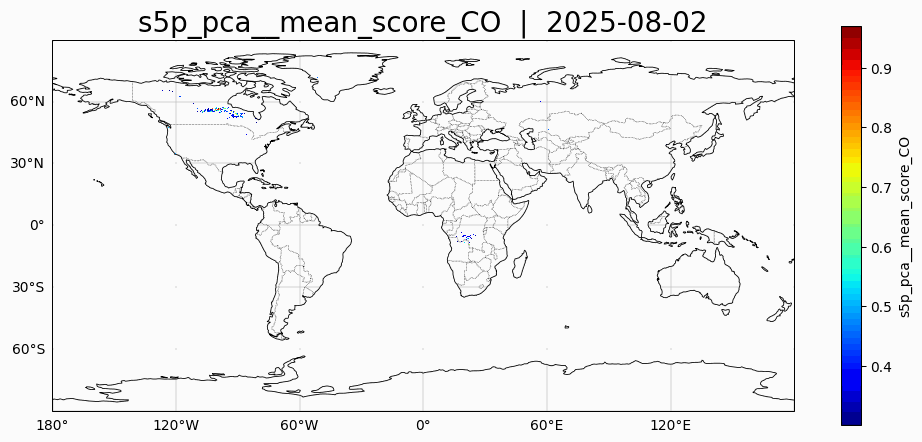

In [8]:
from wekeo_combined_chain.animation.plot import animate_cartes_journalieres

animate_cartes_journalieres(ds,
    varname='s5p_pca__mean_score_CO',
    date_debut=str(start),
    date_fin=str(end),
    duration_ms=400)

## Plot timeseries 

### Timeserie 1: Dayli average fire score

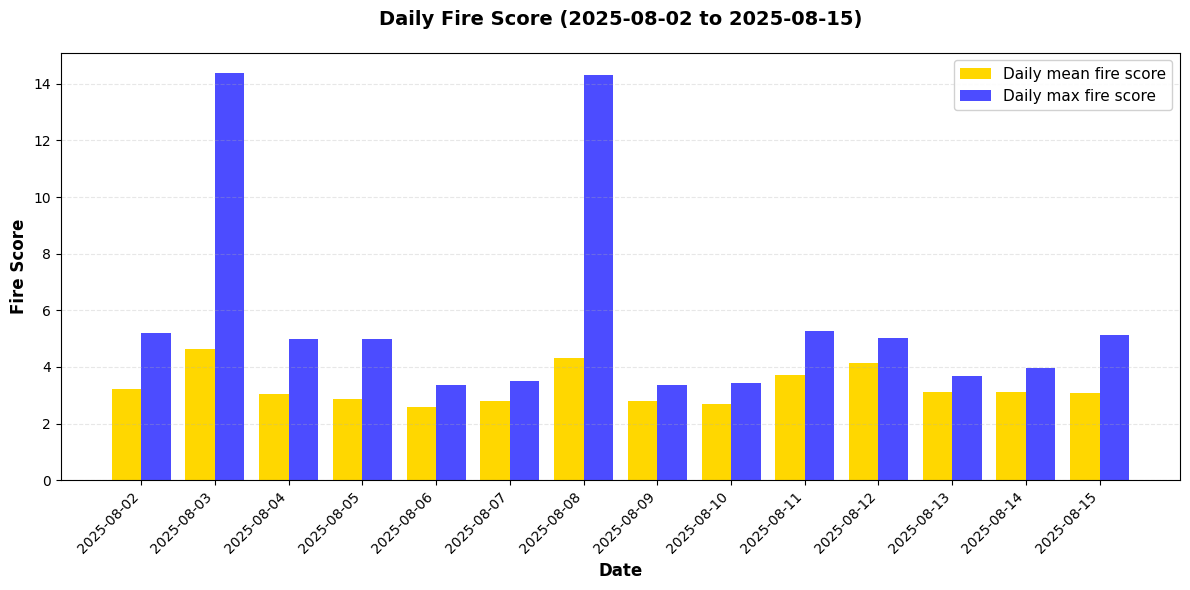

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Daily Fire Score (2025-08-02 to 2025-08-15)'}, xlabel='Date', ylabel='Fire Score'>)

In [9]:
from wekeo_combined_chain.timeseries.plot import plot_fire_score_timeseries

plot_fire_score_timeseries(df_summary)


### Timeserie 2: daily number of sources detected

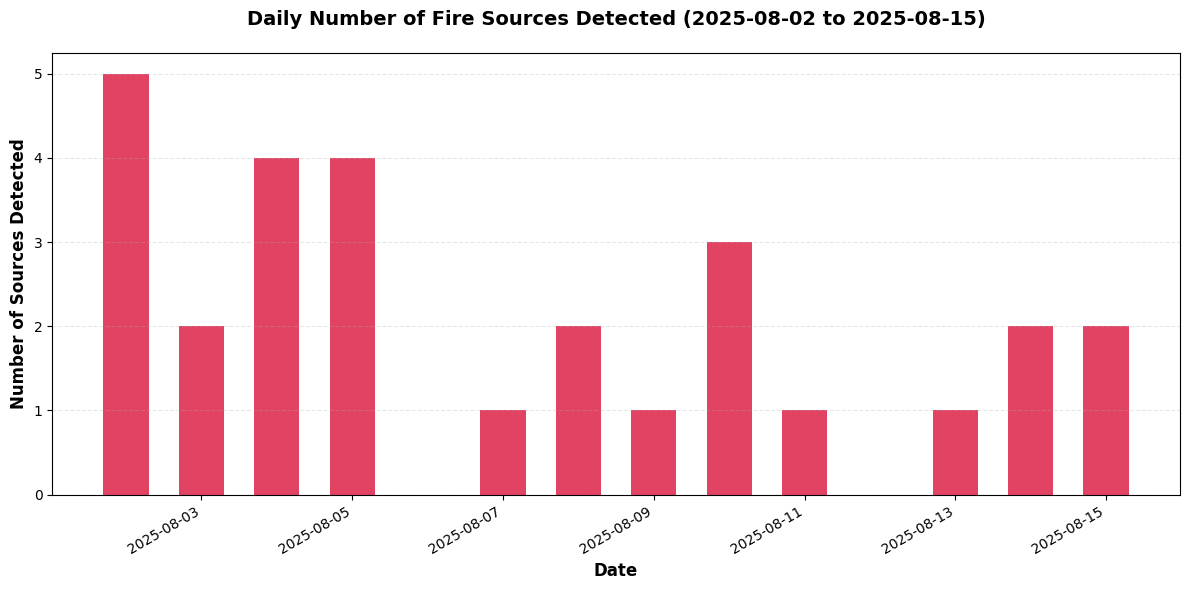

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Daily Number of Fire Sources Detected (2025-08-02 to 2025-08-15)'}, xlabel='Date', ylabel='Number of Sources Detected'>)

In [10]:
from wekeo_combined_chain.timeseries.plot import plot_sources_timeseries
plot_sources_timeseries(df_summary)

### Timeserie 3: plume detection count & pixel counts for plumes

In [11]:
from wekeo_combined_chain.timeseries.plot import plot_plume_timeseries

#fig, ax = plot_plume_timeseries(ds)

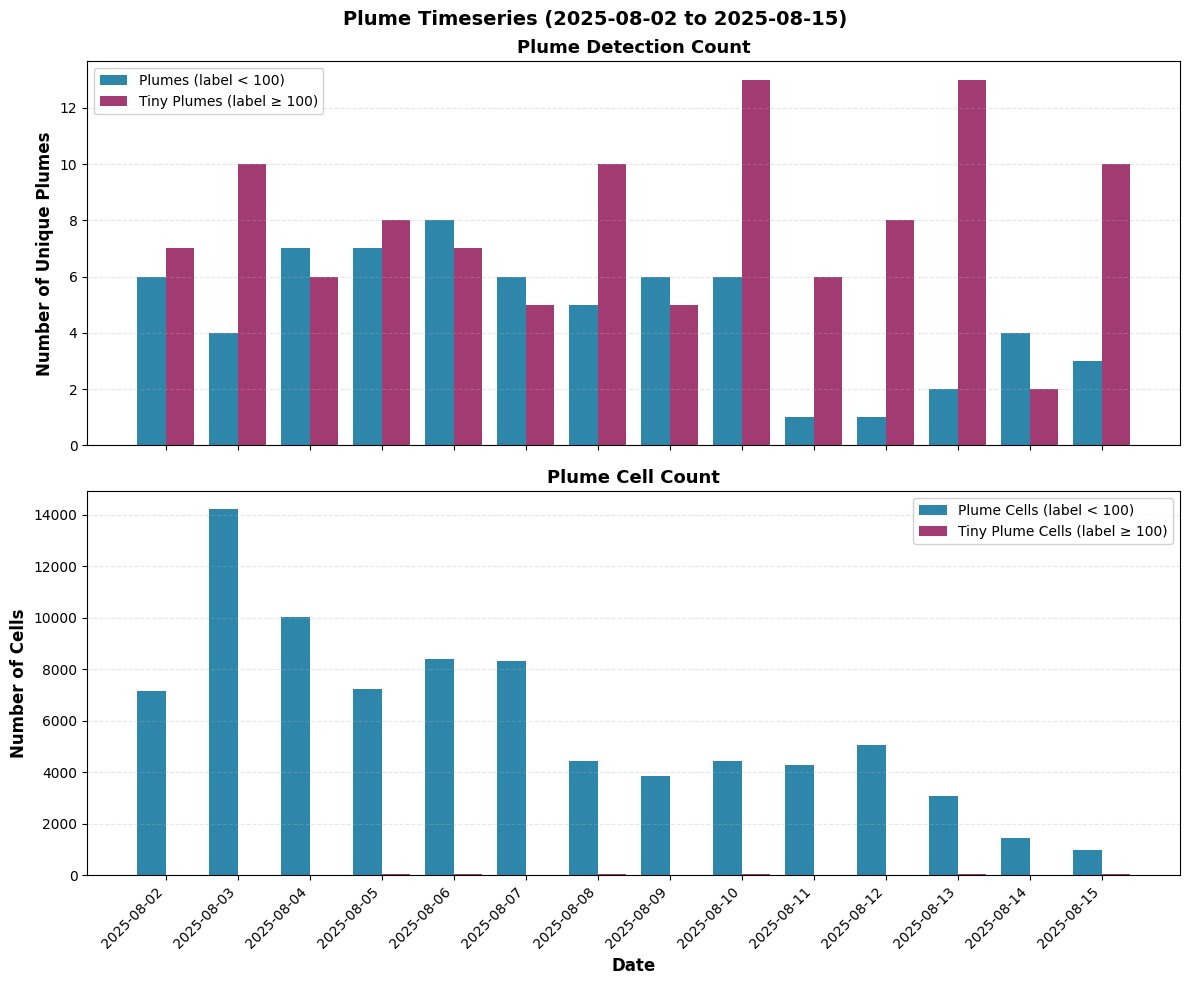

(<Figure size 1200x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Plume Detection Count'}, ylabel='Number of Unique Plumes'>,
        <Axes: title={'center': 'Plume Cell Count'}, xlabel='Date', ylabel='Number of Cells'>],
       dtype=object))

In [12]:
from wekeo_combined_chain.timeseries.plot import plot_plume_pixels_timeseries, plot_plume_combined_timeseries,plot_plume_total_combined_timeseries

# Plot timeseries of pixel counts for normal plumes
#fig, ax = plot_plume_pixels_timeseries(ds, plume_size="normal")

# Plot timeseries of pixel counts for tiny plumes
#fig, ax = plot_plume_pixels_timeseries(ds, plume_size="tiny")

plot_plume_combined_timeseries(ds)


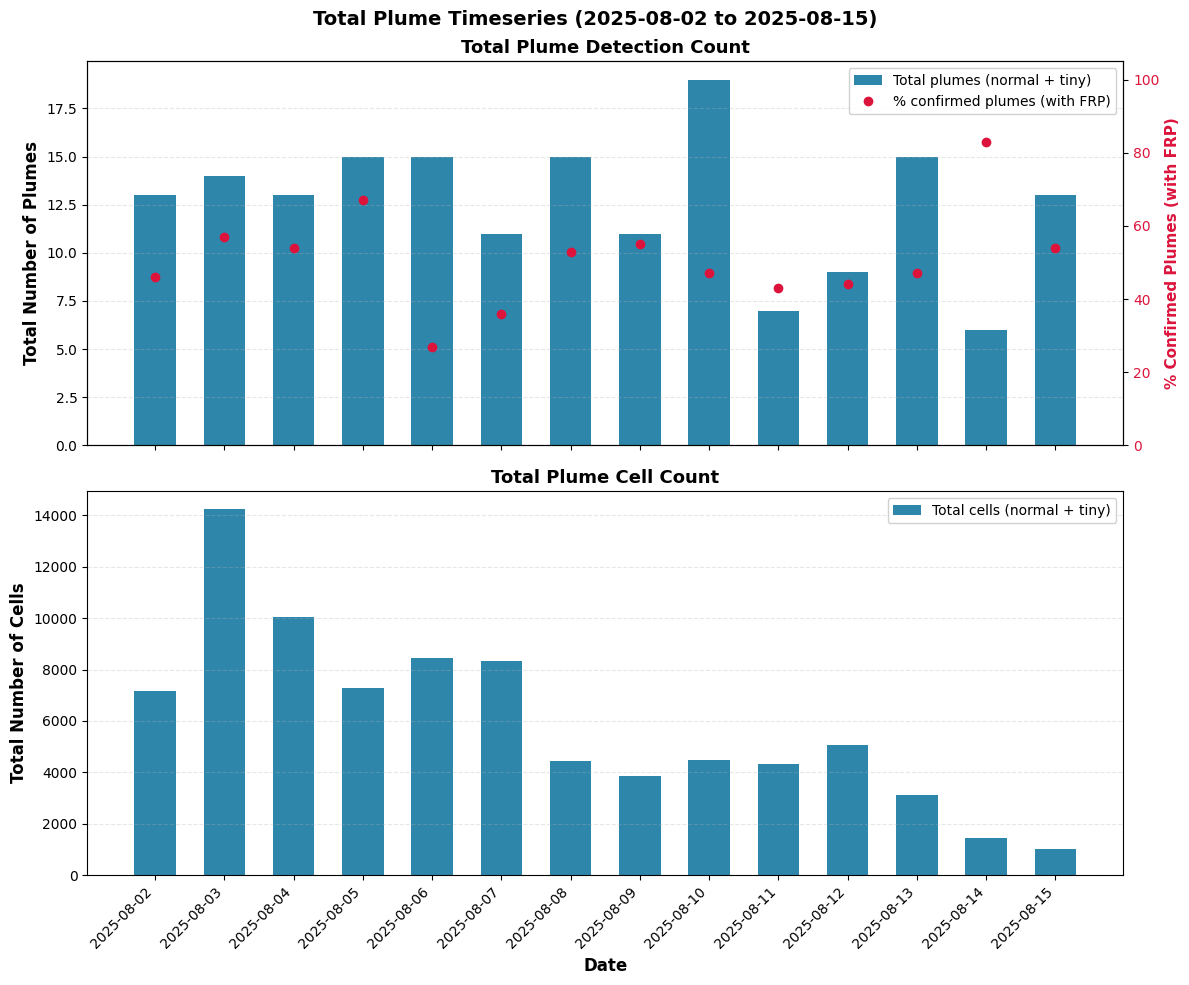

(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Total Plume Detection Count'}, ylabel='Total Number of Plumes'>,
        <Axes: title={'center': 'Total Plume Cell Count'}, xlabel='Date', ylabel='Total Number of Cells'>],
       dtype=object))

In [13]:
from wekeo_combined_chain.timeseries.plot import plot_plume_combined_timeseries,plot_plume_total_combined_timeseries

plot_plume_total_combined_timeseries(ds,df_summary)

5352992


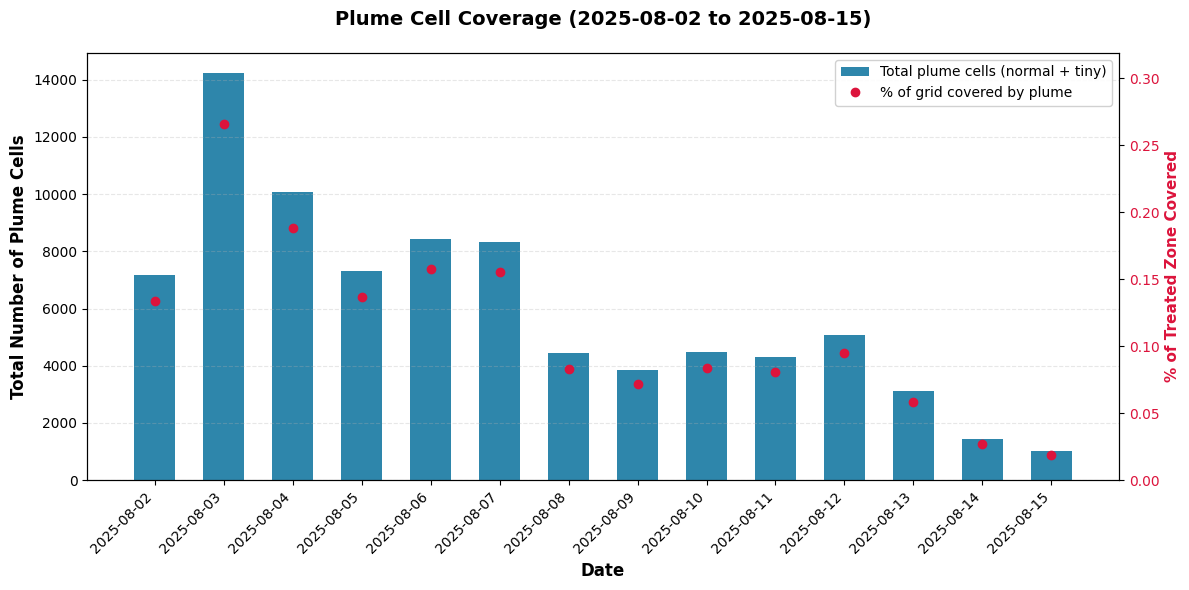

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Plume Cell Coverage (2025-08-02 to 2025-08-15)'}, xlabel='Date', ylabel='Total Number of Plume Cells'>)

In [14]:
from wekeo_combined_chain.timeseries.plot import plot_plume_cell_coverage_timeseries
plot_plume_cell_coverage_timeseries(ds)

### Timeserie 4: number of daily detected pixels

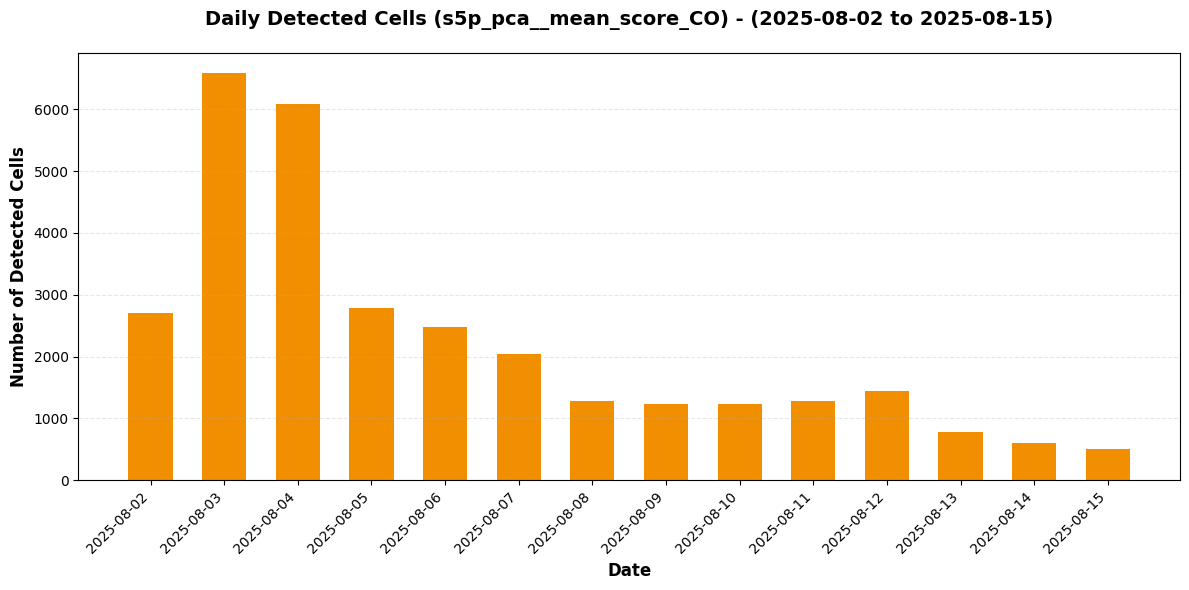

In [15]:
from wekeo_combined_chain.timeseries.plot import plot_detected_pixels_timeseries

# Plot timeseries of daily detected pixels (s5p_pca__mean_score_CO not NaN)
fig, ax = plot_detected_pixels_timeseries(ds)

### Timeserie 5: daily FRP pixels

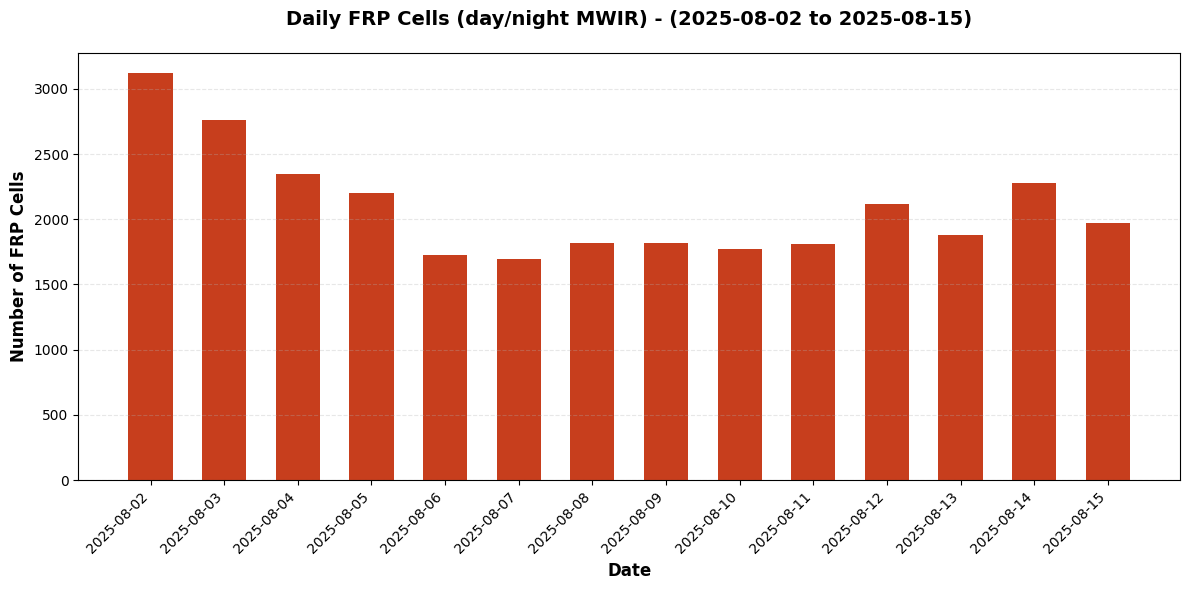

In [16]:
from wekeo_combined_chain.timeseries.plot import plot_frp_pixels_timeseries

# Plot timeseries of daily FRP pixels (day/night MWIR not NaN)
fig, ax = plot_frp_pixels_timeseries(ds)

## Occurrence Maps

In [17]:
"""
Coarsen dataset to reduce spatial resolution by block-averaging.
"""

FACTOR = 4 # 12-16 good on a global scale, for regionnal smaller factor advised, around 4-8
dsc = ds.coarsen(latitude=FACTOR, longitude=FACTOR, boundary="trim").mean()

### Occurence Map 1: plume occurence

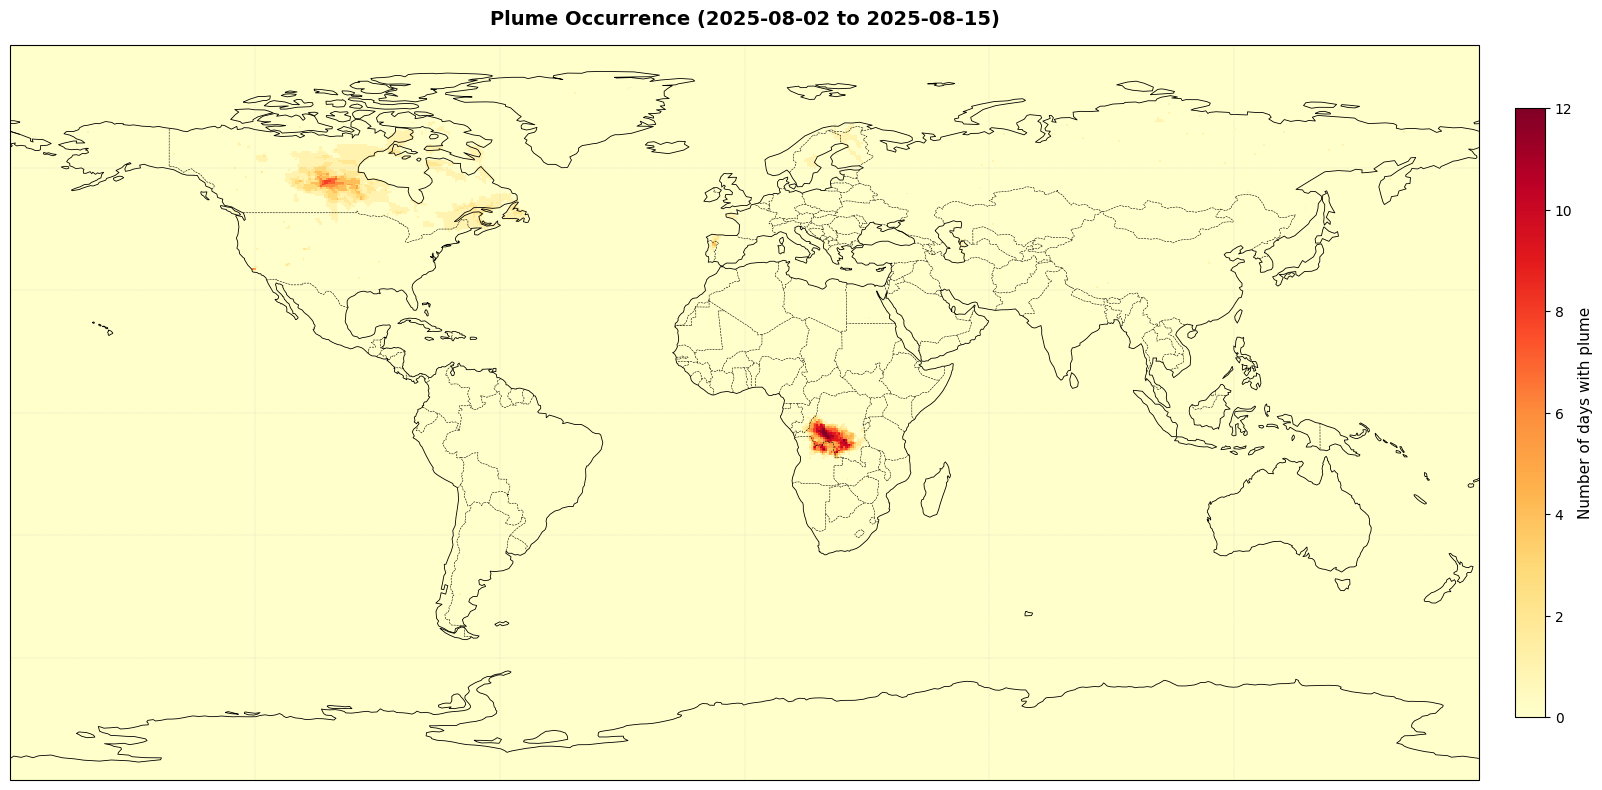

In [18]:
from wekeo_combined_chain.timeseries.plot_maps import plot_plume_occurrence_map

fig, ax = plot_plume_occurrence_map(dsc)


### Occurence Map 2: Detections

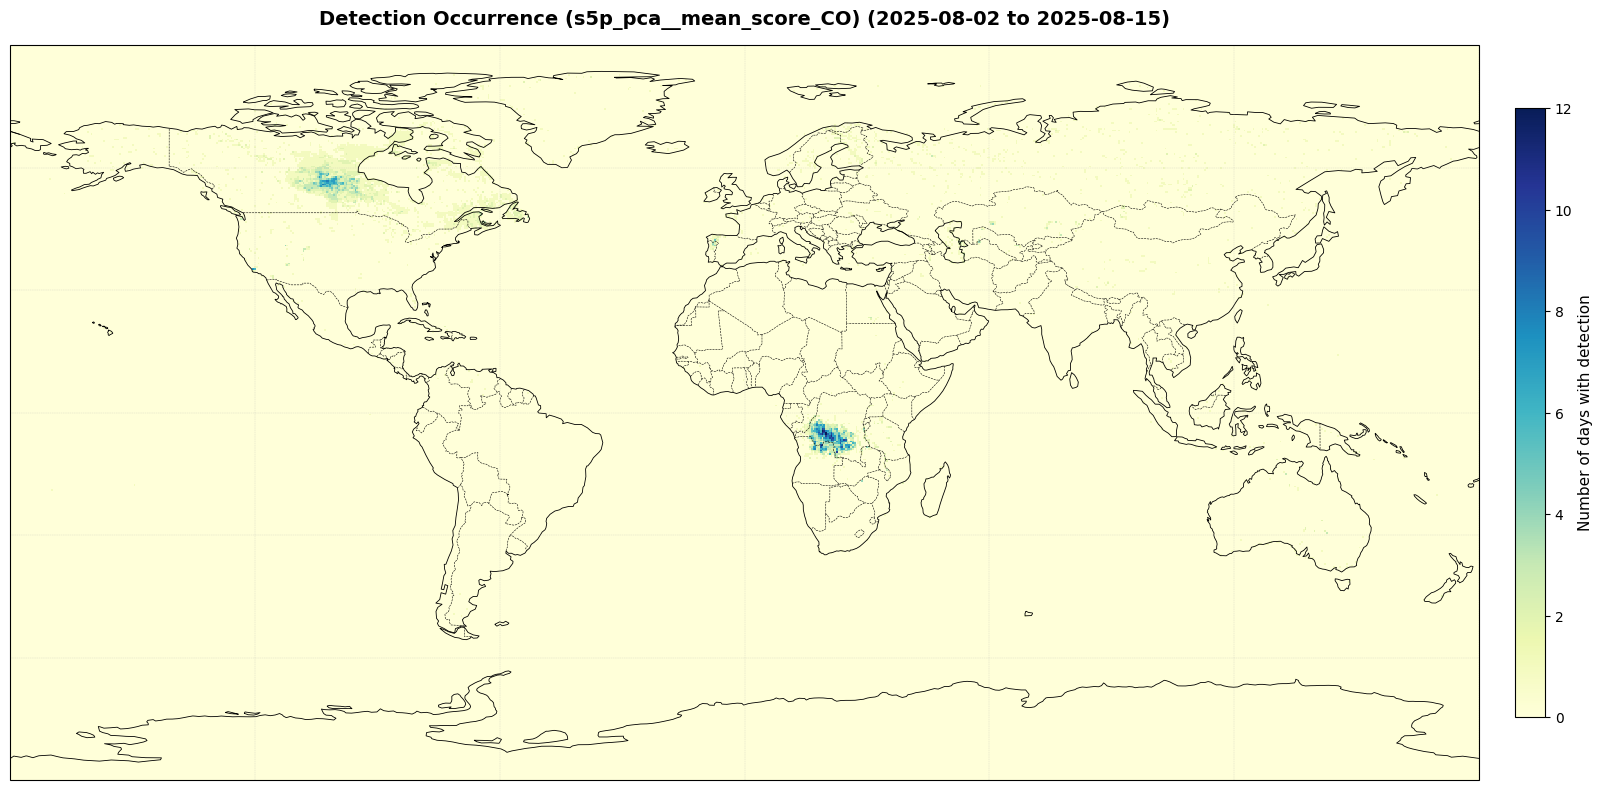

In [19]:
from wekeo_combined_chain.timeseries.plot_maps import plot_detection_occurrence_map

fig, ax = plot_detection_occurrence_map(dsc)


### Occurence map 3: Active Fire Occurence

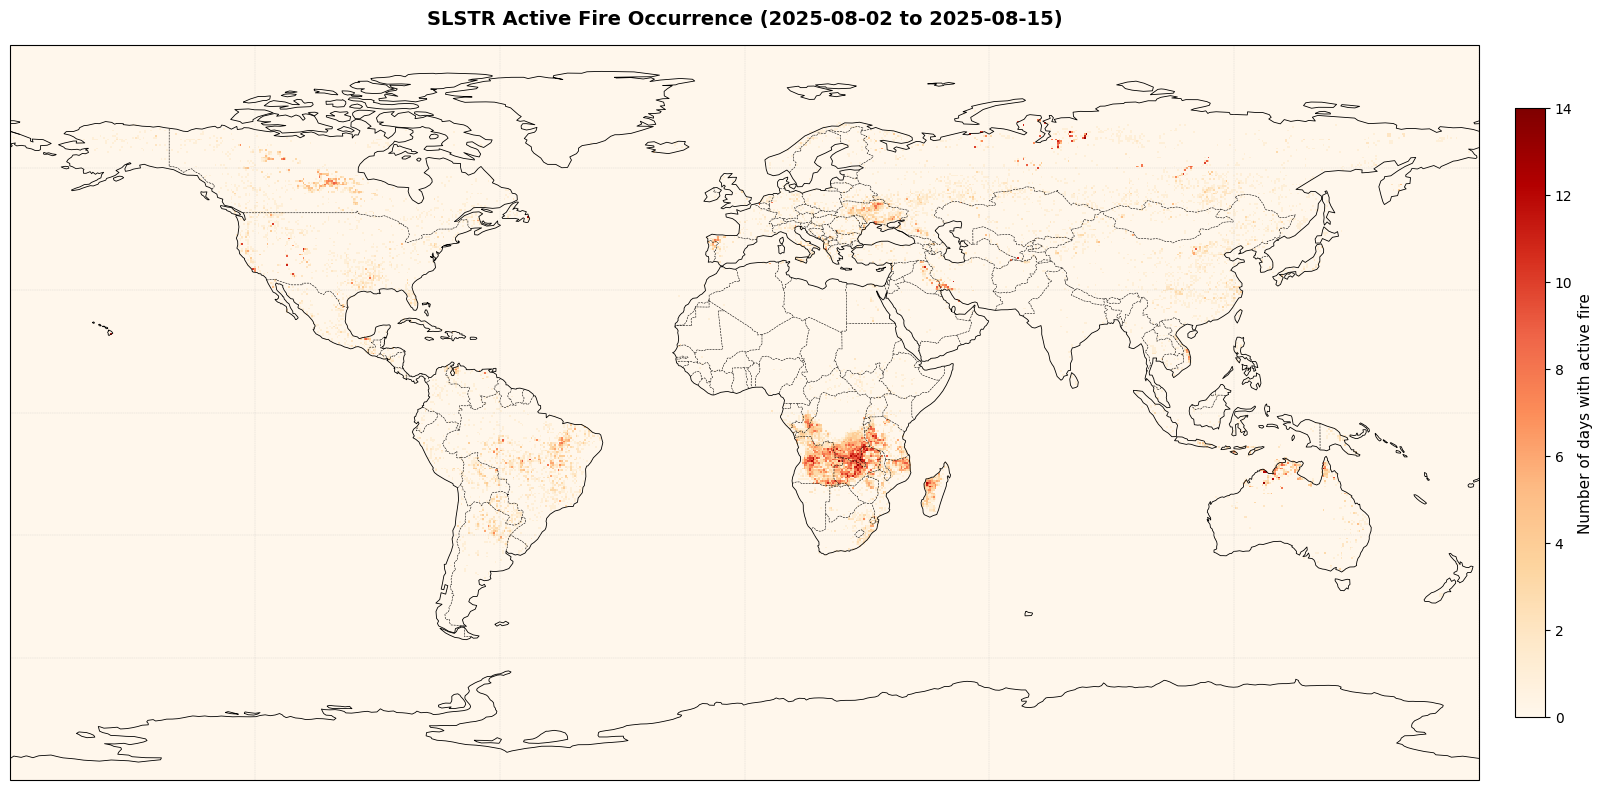

In [20]:
from wekeo_combined_chain.timeseries.plot_maps import plot_fire_occurrence_map

# Note: uses frp_slstr__day_FRP_MWIR_mean (and/or night) to detect active fire days
fig, ax = plot_fire_occurrence_map(dsc)


## Animated Daily Maps

Browse day-by-day through the spatial maps using an interactive slider.
Each function also accepts `save_gif_path` to export the animation as a GIF file.


In [21]:
from wekeo_combined_chain.timeseries.plot_maps import animate_plume_map

# Interactive slider — scrub through days
animate_plume_map(dsc)


Pre-rendering 14 frames… done.


In [22]:
# Export as GIF (uncomment to run)
# animate_plume_map(ds, save_gif_path="plume_animation.gif", fps=2, dpi=100)


In [23]:
from wekeo_combined_chain.timeseries.plot_maps import animate_detection_map

animate_detection_map(dsc)


Pre-rendering 14 frames… done.
